# REATS — Module B Baseline (Kaggle T4)
**ConvNeXt_tiny + Averaging Ensemble** | Target: Accuracy ≥ 92%, ECE ≤ 0.05

Paper: Do et al. (2025), JKSCI Vol.30 No.1

| Step | Cell | Description |
|---|---|---|
| 1 | GPU Check | Detect GPU, set auto batch_size |
| 2 | Install | kornia, grad-cam, shap, mlflow |
| 3 | Repo | Clone REATS branch, add to sys.path |
| 4 | Config | All hyper-parameters in one place |
| 5 | Dataset | Synthetic IR fallback OR real Kaggle dataset |
| 6 | Loaders | ImageFolder → DataLoader |
| 7 | Model | ConvNeXt_tiny + ConvNeXt build |
| 8 | Train | 300-epoch loop, checkpoint from epoch 225 |
| 9 | Evaluate | Test accuracy + ECE |
| 10 | Confusion | Per-class confusion matrix |
| 11 | Grad-CAM | XAI preview (6 samples) |
| 12 | Download | Checkpoint download instructions |

> ⚠ Before running: **Notebook settings → Accelerator → GPU T4 x1**


## 1 · GPU & Environment Check


In [1]:
import torch, sys, platform

print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'Platform: {platform.platform()}')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    p = torch.cuda.get_device_properties(0)
    vram_gb = p.total_memory / 1e9
    print(f'\nGPU  : {p.name}')
    print(f'VRAM : {vram_gb:.1f} GB')
    BATCH_SIZE = 128 if vram_gb >= 20 else 64
    print(f'Auto batch_size → {BATCH_SIZE}  (128 for A100, 64 for T4)')
else:
    print('⚠ No GPU detected — enable in Notebook settings → Accelerator')
    BATCH_SIZE = 16

Python  : 3.12.13
PyTorch : 2.10.0+cu128
Platform: Linux-6.12.90+-x86_64-with-glibc2.35

GPU  : Tesla T4
VRAM : 15.6 GB
Auto batch_size → 64  (128 for A100, 64 for T4)


## 2 · Install Dependencies


In [2]:
import subprocess, sys
pkgs = [
    'kornia>=0.7.0',
    'grad-cam>=1.4.8',
    'shap>=0.44.0',
    'mlflow>=2.10.0',
    'torchmetrics>=1.0.0',
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('All packages installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## 3 · Clone REATS Repository


In [3]:
import subprocess, sys
from pathlib import Path
REPO   = 'https://github.com/trinhvutuandat34/Real-time-Explainable-Automatic-Target-Recognition-System.git'
BRANCH = 'claude/hopeful-mendel-x2y9j7'
TARGET = Path('/kaggle/working/reats')
if TARGET.exists():
    print('Repo exists — pulling latest...')
    subprocess.check_call(['git', '-C', str(TARGET), 'fetch', 'origin', BRANCH])
    subprocess.check_call(['git', '-C', str(TARGET), 'checkout', BRANCH])
    subprocess.check_call(['git', '-C', str(TARGET), 'pull', 'origin', BRANCH])
else:
    subprocess.check_call(['git', 'clone', '-b', BRANCH, '--depth', '1', REPO, str(TARGET)])
if str(TARGET / 'REATS') not in sys.path:
    sys.path.insert(0, str(TARGET / 'REATS'))
from modules.module_b_classifier import (
    KorniaAugmentPipeline, build_convnext, EnsembleClassifier,
    build_loaders, train_one_epoch, evaluate, compute_ece, CLASSES,
)
from modules.module_c_xai import GradCAMExplainer
print('REATS modules loaded OK')

Cloning into '/kaggle/working/reats'...


REATS modules loaded OK


## 4 · Configuration


In [4]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────
DATA_DIR = Path('/kaggle/working/reats/REATS/data')
CKPT_DIR = Path('/kaggle/working/checkpoints')
RUNS_DIR = Path('/kaggle/working/mlruns')
CKPT_DIR.mkdir(exist_ok=True)
RUNS_DIR.mkdir(exist_ok=True)

# ── Dataset source ─────────────────────────────────────────────────────
# Priority (auto-detected in Cell 5):
#   1. FLIR ADAS thermal dataset (deepnewbie/flir-thermal-images-dataset)
#   2. Real REATS Kaggle dataset (set KAGGLE_DATASET to your slug)
#   3. Synthetic-only fallback (no data files required)
FLIR_DIR       = Path('/kaggle/input/flir-thermal-images-dataset')  # mount as Kaggle dataset
KAGGLE_DATASET = None   # e.g. 'reats-ir-images' — your own labelled dataset slug

# ── Training hyper-parameters ───────────────────────────────────────────
EPOCHS           = 300   # paper: 300
BEST_EPOCH_START = 225   # paper: save only from epoch 225
LR               = 1e-4  # paper: AdamW lr=1e-4
NUM_CLASSES      = 6
IMG_SIZE         = 224

CONFIG = dict(
    data_root        = str(DATA_DIR),
    num_classes      = NUM_CLASSES,
    img_size         = IMG_SIZE,
    batch_size       = BATCH_SIZE,
    lr               = LR,
    epochs           = EPOCHS,
    best_epoch_start = BEST_EPOCH_START,
    device           = device,
    classes          = CLASSES,
)
print('Config:')
for k, v in CONFIG.items():
    print(f'  {k:<20} = {v}')

Config:
  data_root            = /kaggle/working/reats/REATS/data
  num_classes          = 6
  img_size             = 224
  batch_size           = 64
  lr                   = 0.0001
  epochs               = 300
  best_epoch_start     = 225
  device               = cuda
  classes              = ['F16', 'LYNX', 'MiG19', 'MiG21', 'PKG', 'PTG']


## 5 · Dataset

Three sources are tried in priority order — the first available wins:

| Priority | Source | How to enable |
|---|---|---|
| 1 | **FLIR ADAS thermal** | Add `deepnewbie/flir-thermal-images-dataset` as a Kaggle input dataset |
| 2 | **Own REATS dataset** | Set `KAGGLE_DATASET` to your labelled-images slug |
| 3 | **Synth-only** | Automatic fallback — no data files needed |

The generator script (`generate_flir_fallback.py`) handles all three paths:
- **FLIR mode**: crops annotated bboxes, intensity-remaps to per-class thermal signature, adds Gaussian target blob
- **Synth-only**: generates plausible IR-like backgrounds + shaped hot target
- Idempotent — re-runs only fill the shortfall toward **170 train / 30 val / 200 test** per class


In [5]:
import subprocess
from pathlib import Path

TARGET = Path('/kaggle/working/reats')   # same as Cell 3 — safe to re-define
FALLBACK_SCRIPT = TARGET / 'REATS' / 'generate_flir_fallback.py'

def _run_fallback(mode, flir_arg=None):
    cmd = ['python', str(FALLBACK_SCRIPT), '--out', str(DATA_DIR), '--mode', mode]
    if flir_arg:
        cmd += ['--flir', str(flir_arg)]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.stdout:
        print(r.stdout)
    if r.returncode != 0:
        print('STDERR:', r.stderr[-2000:])
    return r.returncode == 0

# ── Priority 1: FLIR ADAS dataset ───────────────────────────────────────
if FLIR_DIR.exists() and any(FLIR_DIR.iterdir()):
    print(f'✓ FLIR ADAS found: {FLIR_DIR}')
    print('  Running crop + background modes...')
    ok = _run_fallback('both', flir_arg=FLIR_DIR)
    if not ok:
        print('  FLIR mode failed — falling back to synth-only')
        _run_fallback('synth-only')

# ── Priority 2: labelled Kaggle dataset ─────────────────────────────────
elif KAGGLE_DATASET:
    src = Path(f'/kaggle/input/{KAGGLE_DATASET}')
    assert src.exists(), f'{src} not found — check KAGGLE_DATASET slug'
    import shutil
    print(f'Copying real dataset from {src} ...')
    for split in ['train', 'val', 'test']:
        for cls in CLASSES:
            s = src / split / cls
            if s.exists():
                d = DATA_DIR / split / cls
                d.mkdir(parents=True, exist_ok=True)
                for img in s.iterdir():
                    shutil.copy2(img, d / img.name)
    print('Done copying.')

# ── Priority 3: pure synthetic fallback ─────────────────────────────────
else:
    print('No FLIR dataset found — using synth-only fallback')
    print('  (Add deepnewbie/flir-thermal-images-dataset for higher-quality data)')
    _run_fallback('synth-only')

No FLIR dataset found — using synth-only fallback
  (Add deepnewbie/flir-thermal-images-dataset for higher-quality data)

  REATS Synthetic / FLIR Fallback Generator
  Mode    : synth-only
  Output  : /kaggle/working/reats/REATS/data

──────────────────────────────────────────────────────────
  Shortfall to fill:
    train/F16      → 170 images needed
    train/LYNX     → 170 images needed
    train/MiG19    → 170 images needed
    train/MiG21    → 170 images needed
    train/PKG      → 170 images needed
    train/PTG      → 170 images needed
    val/F16      → 30 images needed
    val/LYNX     → 30 images needed
    val/MiG19    → 30 images needed
    val/MiG21    → 30 images needed
    val/PKG      → 30 images needed
    val/PTG      → 30 images needed
    test/F16      → 200 images needed
    test/LYNX     → 200 images needed
    test/MiG19    → 200 images needed
    test/MiG21    → 200 images needed
    test/PKG      → 200 images needed
    test/PTG      → 200 images needed
───────

In [6]:
import subprocess
r = subprocess.run(
    ['python', str(TARGET / 'REATS' / 'dataset_validator.py'), '--root', str(DATA_DIR)],
    capture_output=True, text=True,
)
print(r.stdout)


  REATS Dataset Report
  Root: /kaggle/working/reats/REATS/data

  [TRAIN]  target: 170 images/class
  Class   Found    Need  Status
  ---------------------------------
  F16       170       0  ✓ OK
  LYNX      170       0  ✓ OK
  MiG19     170       0  ✓ OK
  MiG21     170       0  ✓ OK
  PKG       170       0  ✓ OK
  PTG       170       0  ✓ OK

  [VAL]  target: 30 images/class
  Class   Found    Need  Status
  ---------------------------------
  F16        30       0  ✓ OK
  LYNX       30       0  ✓ OK
  MiG19      30       0  ✓ OK
  MiG21      30       0  ✓ OK
  PKG        30       0  ✓ OK
  PTG        30       0  ✓ OK

  [TEST]  target: 200 images/class
  Class   Found    Need  Status
  ---------------------------------
  F16       200       0  ✓ OK
  LYNX      200       0  ✓ OK
  MiG19     200       0  ✓ OK
  MiG21     200       0  ✓ OK
  PKG       200       0  ✓ OK
  PTG       200       0  ✓ OK

------------------------------------------------------------
  Total:  2400 / 2400 

### Sample images from each class


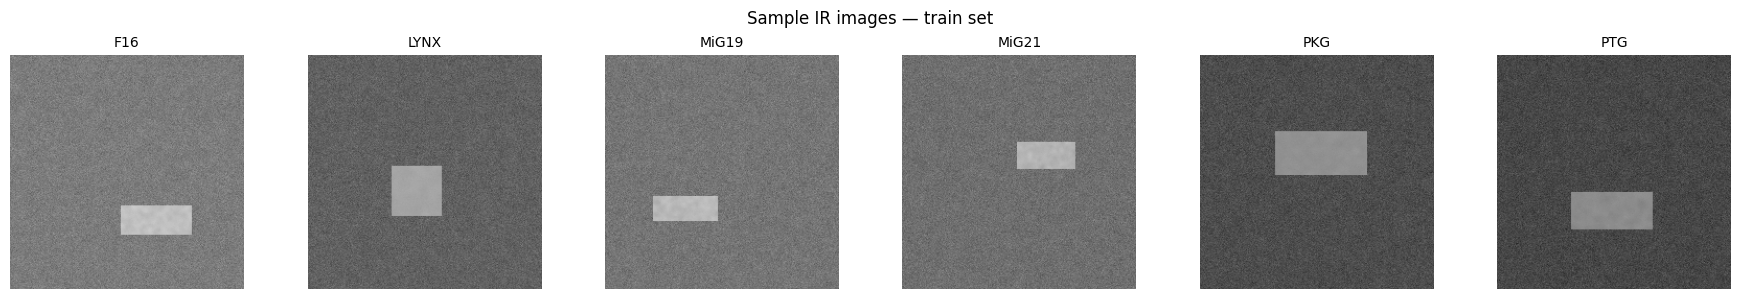

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 3))
for ax, cls in zip(axes, CLASSES):
    imgs = sorted((DATA_DIR / 'train' / cls).glob('*'))[:1]
    if imgs:
        ax.imshow(Image.open(imgs[0]), cmap='gray')
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.suptitle('Sample IR images — train set', fontsize=12)
plt.tight_layout()
plt.show()

## 6 · Data Loaders


In [8]:
train_loader, val_loader, test_loader = build_loaders(CONFIG)

print(f'Train: {len(train_loader.dataset):5d} images  {len(train_loader):3d} batches')
print(f'Val  : {len(val_loader.dataset):5d} images  {len(val_loader):3d} batches')
print(f'Test : {len(test_loader.dataset):5d} images  {len(test_loader):3d} batches')
print(f'Batch size: {BATCH_SIZE}')

Train:  1020 images   16 batches
Val  :   180 images    3 batches
Test :  1200 images   19 batches
Batch size: 64


## 7 · Model


In [9]:
import torch.nn as nn

model        = build_convnext(num_classes=NUM_CLASSES).to(device)
optimizer    = torch.optim.AdamW(model.parameters(), lr=LR)
criterion    = nn.CrossEntropyLoss()
aug_pipeline = KorniaAugmentPipeline().to(device)

CKPT_PATH    = CKPT_DIR / 'convnext_best.pth'
start_epoch  = 1
best_val_acc = 0.0

if CKPT_PATH.exists():
    ckpt = torch.load(CKPT_PATH, map_location=device)
    if isinstance(ckpt, dict) and 'state_dict' in ckpt:
        model.load_state_dict(ckpt['state_dict'])
        start_epoch  = ckpt.get('epoch', 1) + 1
        best_val_acc = ckpt.get('best_val_acc', 0.0)
    else:
        model.load_state_dict(ckpt)
    print(f'Resumed  epoch={start_epoch - 1}  best_val_acc={best_val_acc:.4f}')
else:
    print('No checkpoint — training from scratch')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'ConvNeXt_tiny trainable params: {n_params:.1f}M')

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 185MB/s]


No checkpoint — training from scratch
ConvNeXt_tiny trainable params: 27.8M


## 8 · Training

- Augmentation runs on GPU via Kornia (each transform p=0.5, per Table 1 of the paper)
- Checkpoint saved to `checkpoints/convnext_best.pth` whenever val_acc improves
- Also saves a periodic backup every 25 epochs to survive Kaggle session limits
- MLflow logs to `/kaggle/working/mlruns/`


In [10]:
import sys, importlib

# 1. Evict stale cached modules
for _k in [k for k in sys.modules if 'module_b' in k or 'module_c' in k]:
    del sys.modules[_k]

# 2. Reload fresh from disk
from modules.module_b_classifier import (
    KorniaAugmentPipeline, build_convnext, EnsembleClassifier,
    build_loaders, train_one_epoch, evaluate, compute_ece, CLASSES,
)
from modules.module_c_xai import GradCAMExplainer

# 3. Recreate aug_pipeline with the fixed class
aug_pipeline = KorniaAugmentPipeline().to(device)
print('Reloaded OK —', type(aug_pipeline))

Reloaded OK — <class 'modules.module_b_classifier.KorniaAugmentPipeline'>


In [11]:
import mlflow, time

mlflow.set_tracking_uri(f'sqlite:///{RUNS_DIR}/mlflow.db')
mlflow.set_experiment('REATS-Baseline')

epochs_left = EPOCHS - start_epoch + 1
print(f'Training {epochs_left} epoch(s)  [{start_epoch}..{EPOCHS}]')
print(f'Validation + checkpointing from epoch {BEST_EPOCH_START}')
print(f'Checkpoint path: {CKPT_PATH}\n')

with mlflow.start_run(run_name='ConvNeXt_tiny_baseline'):
    mlflow.log_params(CONFIG)

    for epoch in range(start_epoch, EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, aug_pipeline, device,
        )
        mlflow.log_metrics({'train_loss': tr_loss, 'train_acc': tr_acc}, step=epoch)

        val_note = ''
        if epoch >= BEST_EPOCH_START:
            val_loss, val_acc = evaluate(model, val_loader, criterion, device)
            mlflow.log_metrics({'val_loss': val_loss, 'val_acc': val_acc}, step=epoch)
            val_note = f'  val={val_acc:.4f}'
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(
                    {'state_dict': model.state_dict(),
                     'epoch': epoch,
                     'best_val_acc': best_val_acc},
                    CKPT_PATH,
                )
                val_note += ' ← BEST'

        # Periodic backup every 25 epochs (insurance against session timeout)
        if epoch % 25 == 0:
            torch.save(
                {'state_dict': model.state_dict(), 'epoch': epoch},
                CKPT_DIR / f'convnext_ep{epoch:03d}.pth',
            )

        elapsed = time.time() - t0
        if epoch % 10 == 0 or val_note:
            print(f'[{epoch:3d}/{EPOCHS}]  loss={tr_loss:.4f}  acc={tr_acc:.4f}{val_note}  ({elapsed:.0f}s)')

target_ok = '✓ PASS' if best_val_acc >= 0.92 else ('~ CLOSE' if best_val_acc >= 0.90 else '✗ FAIL')
print(f'\nBest val acc: {best_val_acc:.4f}  {target_ok}  (target ≥ 0.92)')
mlflow.log_metric('best_val_acc', best_val_acc)

2026/06/20 14:02:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/20 14:02:26 INFO mlflow.store.db.utils: Updating database tables
2026/06/20 14:02:29 INFO mlflow.tracking.fluent: Experiment with name 'REATS-Baseline' does not exist. Creating a new experiment.


Training 300 epoch(s)  [1..300]
Validation + checkpointing from epoch 225
Checkpoint path: /kaggle/working/checkpoints/convnext_best.pth

[ 10/300]  loss=0.6339  acc=0.7255  (21s)
[ 20/300]  loss=0.5650  acc=0.7578  (21s)
[ 30/300]  loss=0.5941  acc=0.7510  (21s)
[ 40/300]  loss=0.4243  acc=0.8196  (21s)
[ 50/300]  loss=0.4568  acc=0.7951  (21s)
[ 60/300]  loss=0.5154  acc=0.7755  (21s)
[ 70/300]  loss=0.5352  acc=0.7814  (21s)
[ 80/300]  loss=0.4640  acc=0.8216  (22s)
[ 90/300]  loss=0.4655  acc=0.8118  (21s)
[100/300]  loss=0.4106  acc=0.8324  (21s)
[110/300]  loss=0.4242  acc=0.8088  (21s)
[120/300]  loss=0.4017  acc=0.8314  (21s)
[130/300]  loss=0.3845  acc=0.8422  (20s)
[140/300]  loss=0.3468  acc=0.8618  (21s)
[150/300]  loss=0.4119  acc=0.8324  (21s)
[160/300]  loss=0.3244  acc=0.8647  (21s)
[170/300]  loss=0.3245  acc=0.8627  (21s)
[180/300]  loss=0.3467  acc=0.8471  (21s)
[190/300]  loss=0.3940  acc=0.8275  (21s)
[200/300]  loss=0.4661  acc=0.8118  (21s)
[210/300]  loss=0.2549

## 9 · Evaluation — Test Set


In [12]:
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['state_dict'] if 'state_dict' in ckpt else ckpt)
model.eval()

_, test_acc = evaluate(model, test_loader, criterion, device)
ece         = compute_ece(model, test_loader, device)

def _check(val, target, op='ge'):
    ok = val >= target if op == 'ge' else val <= target
    return '✓ PASS' if ok else '✗ FAIL'

print(f'Test Accuracy : {test_acc:.4f}  {_check(test_acc, 0.92)}  (target ≥ 0.92)')
print(f'ECE           : {ece:.4f}   {_check(ece, 0.05, "le")}  (target ≤ 0.05)')

Test Accuracy : 0.9967  ✓ PASS  (target ≥ 0.92)
ECE           : 0.0073   ✓ PASS  (target ≤ 0.05)


## 10 · Confusion Matrix


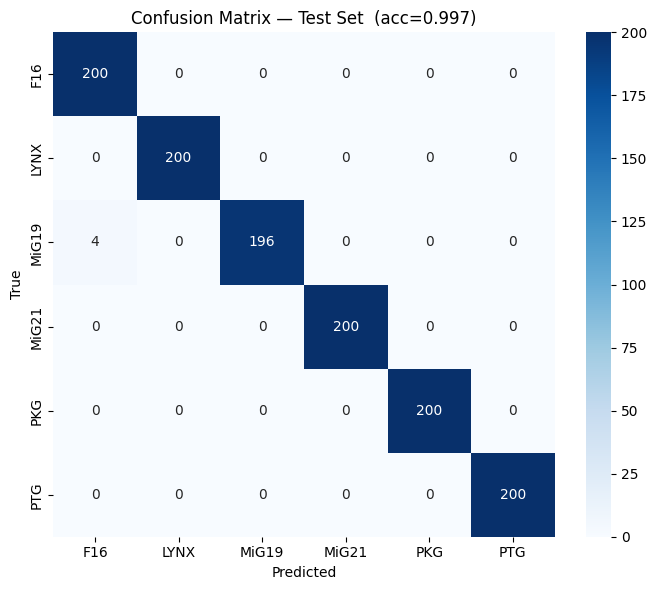

Fighter confusion (hardest per paper):
  F16    →  F16:200  MiG19:0  MiG21:0
  MiG19  →  F16:4  MiG19:196  MiG21:0
  MiG21  →  F16:0  MiG19:0  MiG21:200


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Test Set  (acc={test_acc:.3f})')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()
print('Fighter confusion (hardest per paper):')
fighter_idx = [CLASSES.index(c) for c in ['F16','MiG19','MiG21']]
for i in fighter_idx:
    row = cm[i, fighter_idx]
    print(f'  {CLASSES[i]:<6} →  ' + '  '.join(f'{CLASSES[j]}:{v}' for j, v in zip(fighter_idx, row)))

## 11 · Grad-CAM Preview (Module C)

Quick sanity check — the heatmap should light up the target region, not the background.


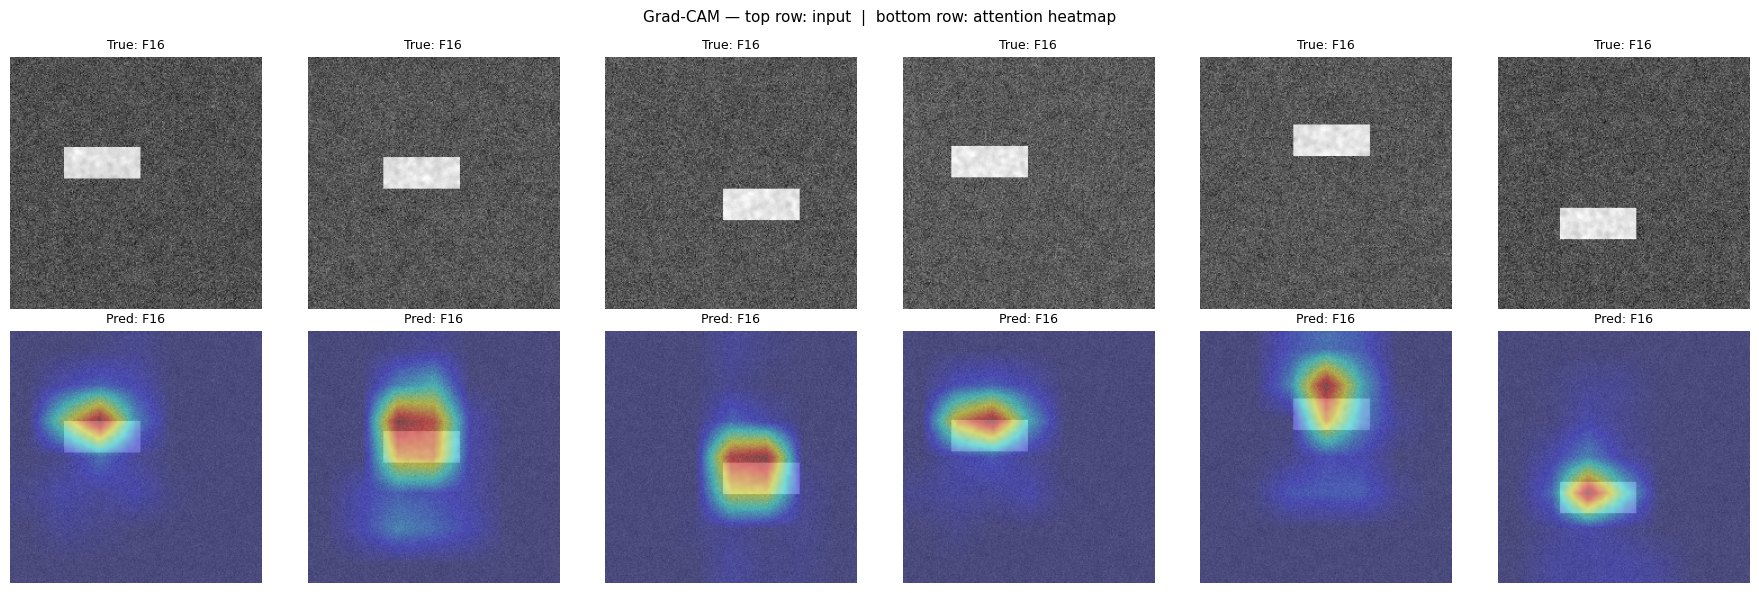

Saved: /kaggle/working/gradcam_preview.png


In [14]:
import cv2, numpy as np

try:
    gradcam = GradCAMExplainer(model)
    sample_imgs, sample_labels = next(iter(test_loader))
    sample_imgs = sample_imgs[:6].to(device)

    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    model.eval()
    for i in range(6):
        x       = sample_imgs[i:i+1]
        pred    = model(x).argmax(1).item()
        heatmap = gradcam.explain(x, pred)

        # Denormalise image: mean=0.5 std=0.5
        orig = (sample_imgs[i].cpu().permute(1,2,0).numpy() * 0.5 + 0.5)
        orig = (orig * 255).clip(0,255).astype(np.uint8)
        gray = orig[..., 0] if orig.ndim == 3 else orig

        hmap  = cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_JET)
        hmap  = cv2.cvtColor(hmap, cv2.COLOR_BGR2RGB)
        over  = cv2.addWeighted(cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB), 0.6, hmap, 0.4, 0)

        axes[0,i].imshow(gray, cmap='gray')
        axes[0,i].set_title(f'True: {CLASSES[sample_labels[i]]}', fontsize=9)
        axes[0,i].axis('off')
        axes[1,i].imshow(over)
        axes[1,i].set_title(f'Pred: {CLASSES[pred]}', fontsize=9)
        axes[1,i].axis('off')

    fig.suptitle('Grad-CAM — top row: input  |  bottom row: attention heatmap', fontsize=11)
    plt.tight_layout()
    plt.savefig('/kaggle/working/gradcam_preview.png', dpi=150)
    plt.show()
    print('Saved: /kaggle/working/gradcam_preview.png')
except Exception as e:
    print(f'Grad-CAM error: {e}')

## 12 · Download Artifacts & Next Steps


In [15]:
import os
print('━'*50)
print('  Artifacts saved in /kaggle/working/')
print('━'*50)
for p in sorted(Path('/kaggle/working').rglob('*')):
    if p.is_file() and p.suffix in {'.pth', '.png', '.yaml'}:
        size_kb = p.stat().st_size / 1024
        print(f'  {str(p.relative_to("/kaggle/working")):45s}  {size_kb:7.1f} KB')
print('━'*50)
print()
print('⚠  /kaggle/working/ is wiped when the session ends.')
print('   Download checkpoints/convnext_best.pth BEFORE closing.')
print()
print('Next steps:')
print('  • acc ≥ 0.92  → Done — commit checkpoint, move to Module A')
print('  • acc 0.90-0.92 → Train 6 models → EnsembleClassifier (paper: +2pp)')
print('  • acc < 0.90  → Check data quality, increase epochs')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Artifacts saved in /kaggle/working/
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  checkpoints/convnext_best.pth                  108756.7 KB
  checkpoints/convnext_ep025.pth                 108756.9 KB
  checkpoints/convnext_ep050.pth                 108756.9 KB
  checkpoints/convnext_ep075.pth                 108756.9 KB
  checkpoints/convnext_ep100.pth                 108756.9 KB
  checkpoints/convnext_ep125.pth                 108756.9 KB
  checkpoints/convnext_ep150.pth                 108756.9 KB
  checkpoints/convnext_ep175.pth                 108756.9 KB
  checkpoints/convnext_ep200.pth                 108756.9 KB
  checkpoints/convnext_ep225.pth                 108756.9 KB
  checkpoints/convnext_ep250.pth                 108756.9 KB
  checkpoints/convnext_ep275.pth                 108756.9 KB
  checkpoints/convnext_ep300.pth                 108756.9 KB
  confusion_matrix.png                              51.9 KB
  gradc